In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR
from torch.utils.data import WeightedRandomSampler
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm
import json
import cv2
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import  plot_some_images ,read_images , pre_hard_skeletonize , pre_soft_skeletonize,compute_confution_matrix
from utils.preprocessing import WhiteTopHat , CLAHE , normalize_xca
from utils.dataset import  UnetDataset , ValidUnetDataset
from models.nnunet import nnUnet
from models.nnunet_blocks import nnUnetv2
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [ ]:
args = {
    "base_path" : "../arcade/nnUnet_dataset/syntax",
    "in_c" : 1,
    "base_channel" :32,
    "image_shape" : (448,448),
    "class_count" : 26 ,
    "attention" : True,
    "k":40,
    "batch_size" : 10,
    "num_workers" : 10,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.01,
    "momentum" : 0.99,
    "weight_decay" : 3e-5,
    "epcohs":200,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "input_channels":1,
    "unet_depth":6,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.00,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":0.5,"Second":1.0},
    "output_base_path" : "./outputs",
    "name" : "Attention7-DSV-tev-new_augs-binary2color",
    "deep_super_vision" : True,
    "f_alpha":None
}
class_map = {
    1: '1',2: '2', 3: '3',4: '4',
    5: '5',6: '6',7: '7',8: '8',
    9: '9',10: '9a',11: '10',12: '10a',
    13: '11',14: '12',15: '12a',16: '13',
    17: '14',18: '14a',19: '15',20: '16',
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b'
}
train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","CE loss",args["loss_type"]]
out_counts = 6 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]

In [3]:
def class_weighting(method,class_counts,**kwargs):
    if(kwargs["use_pixel_counts"]):
        print("using pixel counts")
        with open("./data/train_class_counts.json","r") as f:
            train_class_counts = json.load(f)
        counts = [0]*(len(train_class_counts))
        for k,v in train_class_counts.items():
            counts[int(k)] = int(v)
        counts = np.array(counts,dtype=np.float64)
    else :
        print("using class counts")
        counts = np.array(class_counts,dtype=np.float64)

    if(method=="median"):
        print("median weights being used")
        median_count = np.median(counts)
        weights = median_count/np.array(counts)
        
    elif(method=="log"):
        print("log weights being used")
        total = np.sum(counts)
        weights = np.log(total/np.array(counts))
        weights = (weights / weights.mean())
        weights[0]=0.1
    elif(method=="beta"):
        print("beta weights being used")
        b = kwargs["b"]
        weights = (1-b)/(1-np.power(b,counts))
        weights = weights / weights.sum()
        weights[12] = 0.25
    else:
        print("no class weights being used")
        return None
    return weights.tolist()
args["f_alpha"] = class_weighting(method="median",class_counts=train_class_counts,b=0.999999,use_pixel_counts=False)
args["f_alpha"]

using class counts
median weights being used


[0.1635,
 0.43716577540106955,
 0.436,
 0.44308943089430897,
 0.5396039603960396,
 0.31142857142857144,
 0.31142857142857144,
 0.4808823529411765,
 0.5274193548387097,
 0.8257575757575758,
 2.335714285714286,
 7.785714285714286,
 163.5,
 0.5109375,
 2.680327868852459,
 1.2674418604651163,
 0.5360655737704918,
 1.52803738317757,
 3.336734693877551,
 4.302631578947368,
 0.7047413793103449,
 3.802325581395349,
 3.40625,
 5.274193548387097,
 2.5952380952380953,
 1.2874015748031495]

In [4]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [5]:
train_transforms = A.Compose([
    A.Resize(*args["image_shape"]),

    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.7),


    A.Affine(
        scale=(0.8, 1.2),             
        translate_percent=(-0.1, 0.1), 
        rotate=(-30, 30),         
        shear=(-10, 10),      
        

        fill=0,           
        fill_mask=0,                 
        border_mode=cv2.BORDER_CONSTANT, 
        
        fit_output=False,  
        p=0.7
    ),

    # A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

    # A.RandomBrightnessContrast(
    #     brightness_limit=0.2, 
    #     contrast_limit=0.2, 
    #     p=0.5
    # ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    
    # A.Lambda(image=normalize_xca)
])
test_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    # A.Lambda(image=normalize_xca),
    ToTensorV2()
    ]  
)
# train_preprocess = v2.Compose([
#     WhiteTopHat(kernel_size=(50,50)),
#     CLAHE()
    
# ])
train_preprocess = None


In [6]:
def make_dataloader(data,args,valid=False,sampler_weights=None):
    if(sampler_weights is not None):
        print("using weighted sampler here")
        sampler = WeightedRandomSampler(sampler_weights, len(sampler_weights))
        dataloader = DataLoader(
            data,
            batch_size = args["batch_size"] ,
            num_workers = args["num_workers"] ,
            pin_memory=True,
            shuffle=False,
            sampler=sampler
        )
        
    else : 
        if(valid):
            print("valid with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=False,
            )
        else : 
            print("train with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=True
            )
    return dataloader

In [7]:

train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_class_counts),
    # mode = args["train_mode"]
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None,
    # mode = args["train_mode"]
)
train_ds = UnetDataset(transform = train_transforms,data = train_images,base_size=args["image_shape"][0],out_counts=out_counts)
valid_ds = ValidUnetDataset(transform = test_transforms,data = valid_images)

train_loader = make_dataloader(train_ds,args,valid=False,sampler_weights=sampler_weights)
valid_loader = make_dataloader(valid_ds,args,valid=True,sampler_weights=None)

max count is :  525
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

using weighted sampler here
valid with no sampler


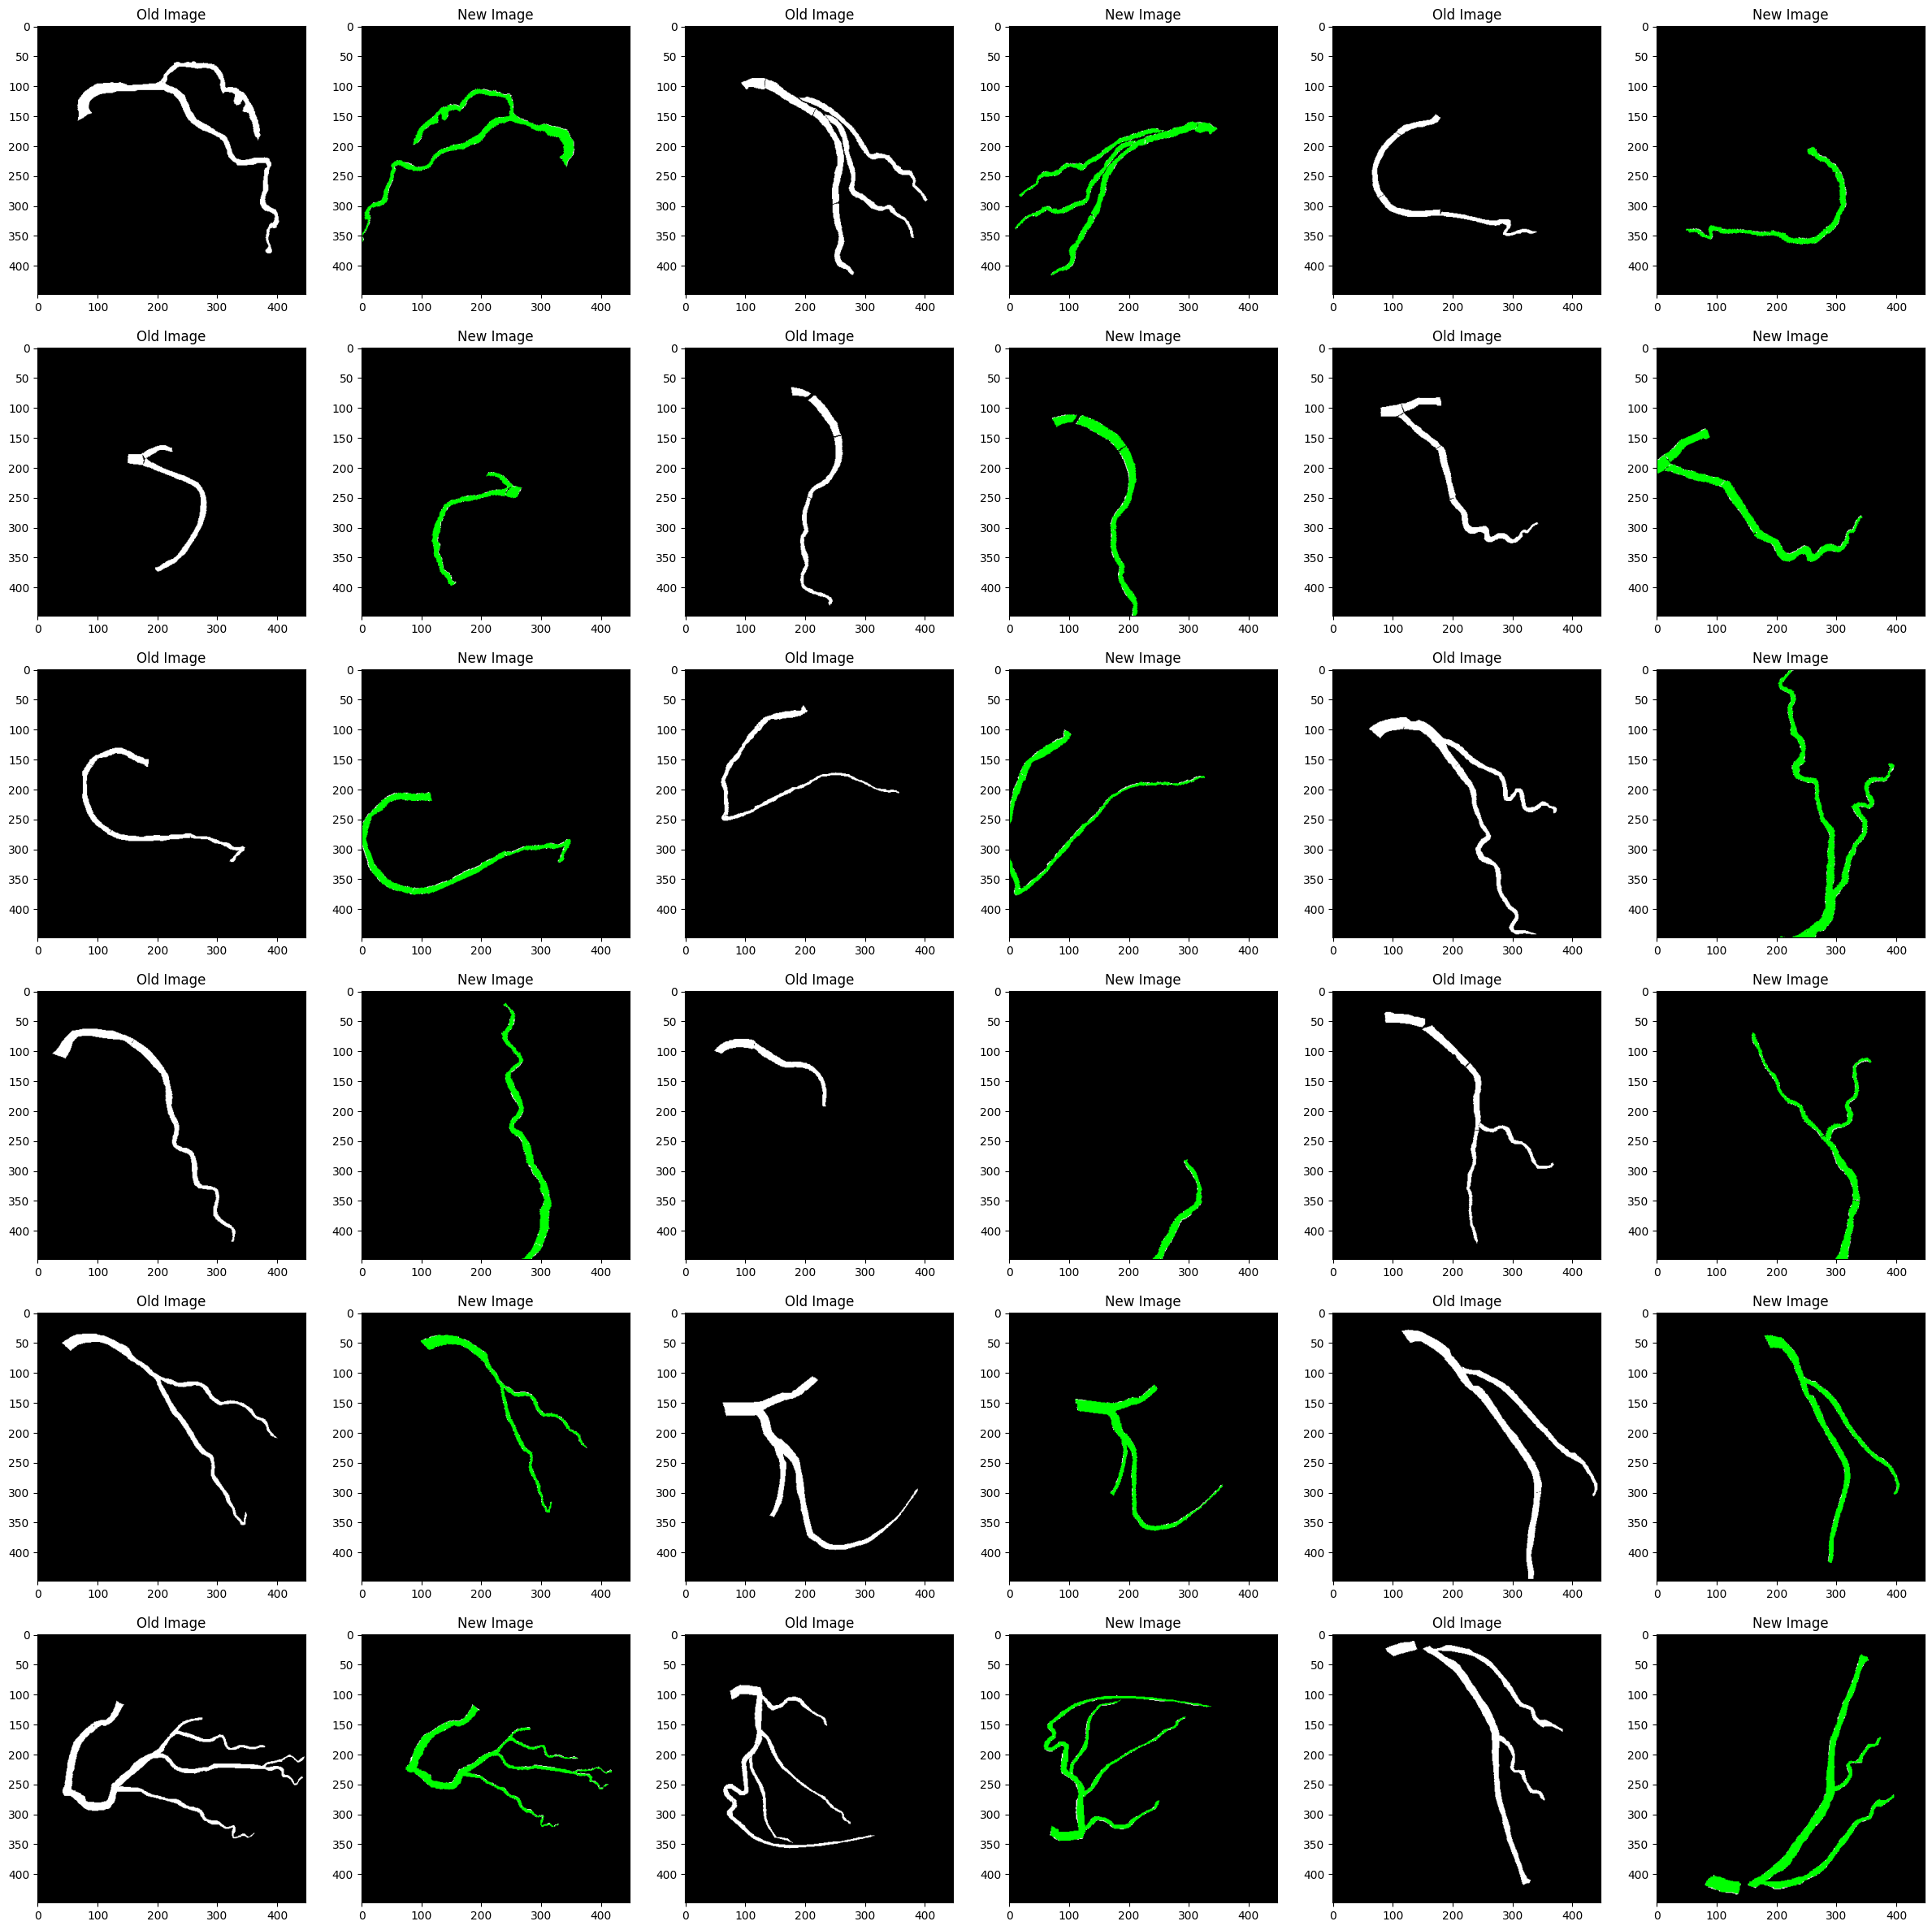

In [8]:
plot_some_images(train_images, train_transforms, image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [ ]:
model = nnUnet(args).to(args["device"])
loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     momentum=args["momentum"],
#     lr=args["lr"],
#     nesterov=True,
#     weight_decay=args["weight_decay"]
# )
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=0.001, 
    betas=(0.9, 0.999), 
    eps=1e-08, 
    weight_decay=0.01
)
lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map)

best_model =trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)

number of layers : 6
encoder settings :  [32, 64, 128, 256, 512, 512]
bottle-neck settings :  1024
decoder settings :  [1024, 512, 256, 128, 64]
head settings :  26
loss is set to tversky


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 0.01
train ==> epcoh (0)
total loss : 3.1014930701255796 - CE loss : 1.1883277985453606 - tversky loss : 1.913165272474289

train avg metrics for epoch 0 :
avg dice : 0.003227214288907808 - avg precision : 0.006272503567161038 - avg recall : 0.038094669465690456
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.2930196523666382 - CE loss : 0.3332662433385849 - tversky loss : 0.95975341796875

valid avg metrics for epoch 0 :
avg dice : 0.00014837686945002196 - avg precision : 7.43265775963664e-05 - avg recall : 0.03991689682006836
------------------------------------------------------------
New Best! : dice = 0.00014837687194813043


  0%|          | 0/100 [00:00<?, ?it/s]

...

current lr : 0.0002283
train ==> epcoh (197)
total loss : 0.36825641095638273 - CE loss : 0.09679090132936835 - tversky loss : 0.27146551124751567

train avg metrics for epoch 197 :
avg dice : 0.7994752979278564 - avg precision : 0.7486701941490174 - avg recall : 0.8656787586212158
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (197)
total loss : 0.6583307236433029 - CE loss : 0.40475595071911813 - tversky loss : 0.2535747788846493

valid avg metrics for epoch 197 :
avg dice : 0.5916734179854393 - avg precision : 0.5864688977599144 - avg recall : 0.632873103171587
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 0.0001585
train ==> epcoh (198)
total loss : 0.35015650793910025 - CE loss : 0.08754279013723135 - tversky loss : 0.26261371687054635

train avg metrics for epoch 198 :
avg dice : 0.8002623438835144 - avg precision : 0.7491401600837707 - avg recall : 0.8692130517959594
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (198)
total loss : 0.6740921378135681 - CE loss : 0.4226151656359434 - tversky loss : 0.25147697031497956

valid avg metrics for epoch 198 :
avg dice : 0.5960200855135918 - avg precision : 0.5955837135016918 - avg recall : 0.6374490147829056
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 8.493e-05
train ==> epcoh (199)
total loss : 0.3595380041003227 - CE loss : 0.09706359975039959 - tversky loss : 0.26247440129518507

train avg metrics for epoch 199 :
avg dice : 0.8000908994674683 - avg precision : 0.7494881439208985 - avg recall : 0.8663049292564392
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (199)
total loss : 0.6658487364649772 - CE loss : 0.41569594778120517 - tversky loss : 0.2501527853310108

valid avg metrics for epoch 199 :
avg dice : 0.5962578661739826 - avg precision : 0.5921410216391086 - avg recall : 0.6378810656815768
1 => dice : 0.9040220379829407 p : 0.8976333141326904 , r : 0.9105023741722107
2 => dice : 0.8175628781318665 p : 0.8181759715080261 , r : 0.8169507384300232
3 => dice : 0.8186222910881042 p : 0.7814666628837585 , r : 0.8594874739646912
4 => dice : 0.8593406677246094 p : 0.8276844024658203 , r : 0.8935148119926453
5 => dice : 0.8880872130393982 p : 0.9015260338783264 , r : 0.8750431537628174
6 =>

Save Model
Saving Memory
Saving All Plots


  0%|          | 0/20 [00:00<?, ?it/s]

Saving Examples


  0%|          | 0/18 [00:00<?, ?it/s]

Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 9/9 [00:00<00:00, 1737.09it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  2.81it/s]

processing ./temp_script.py


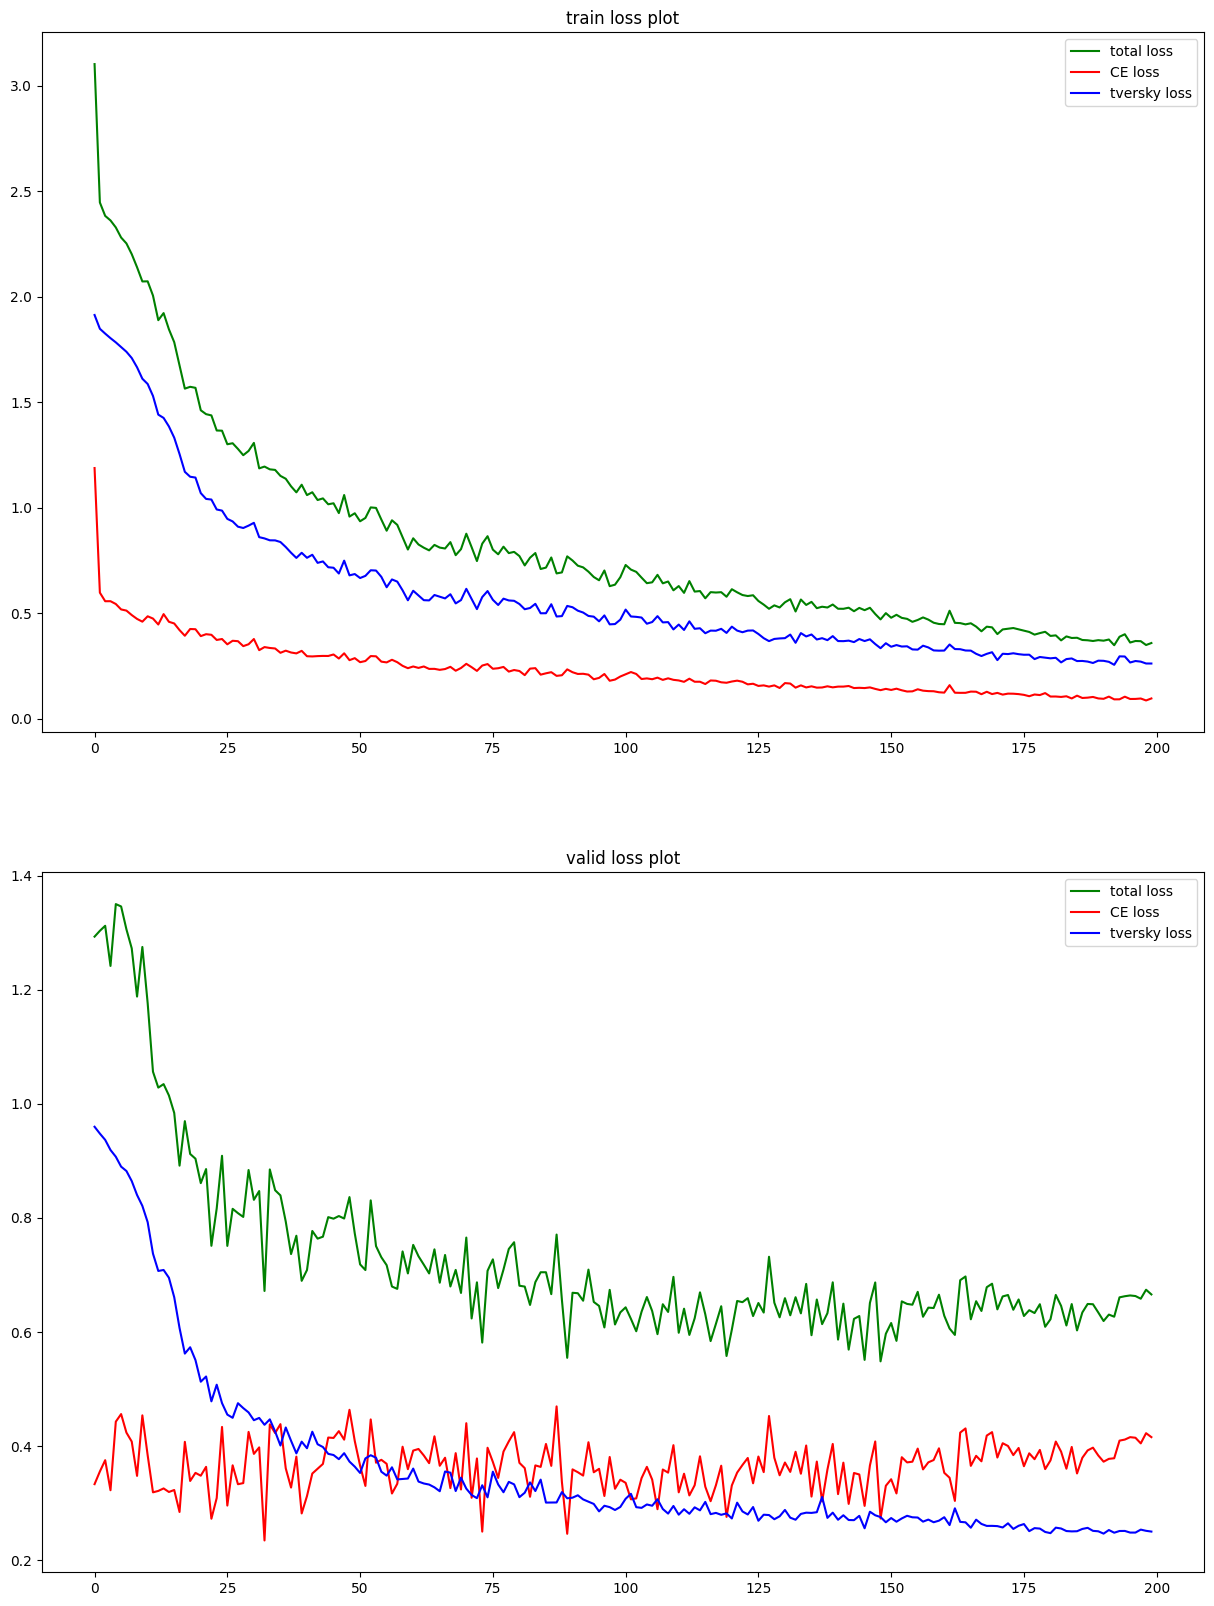

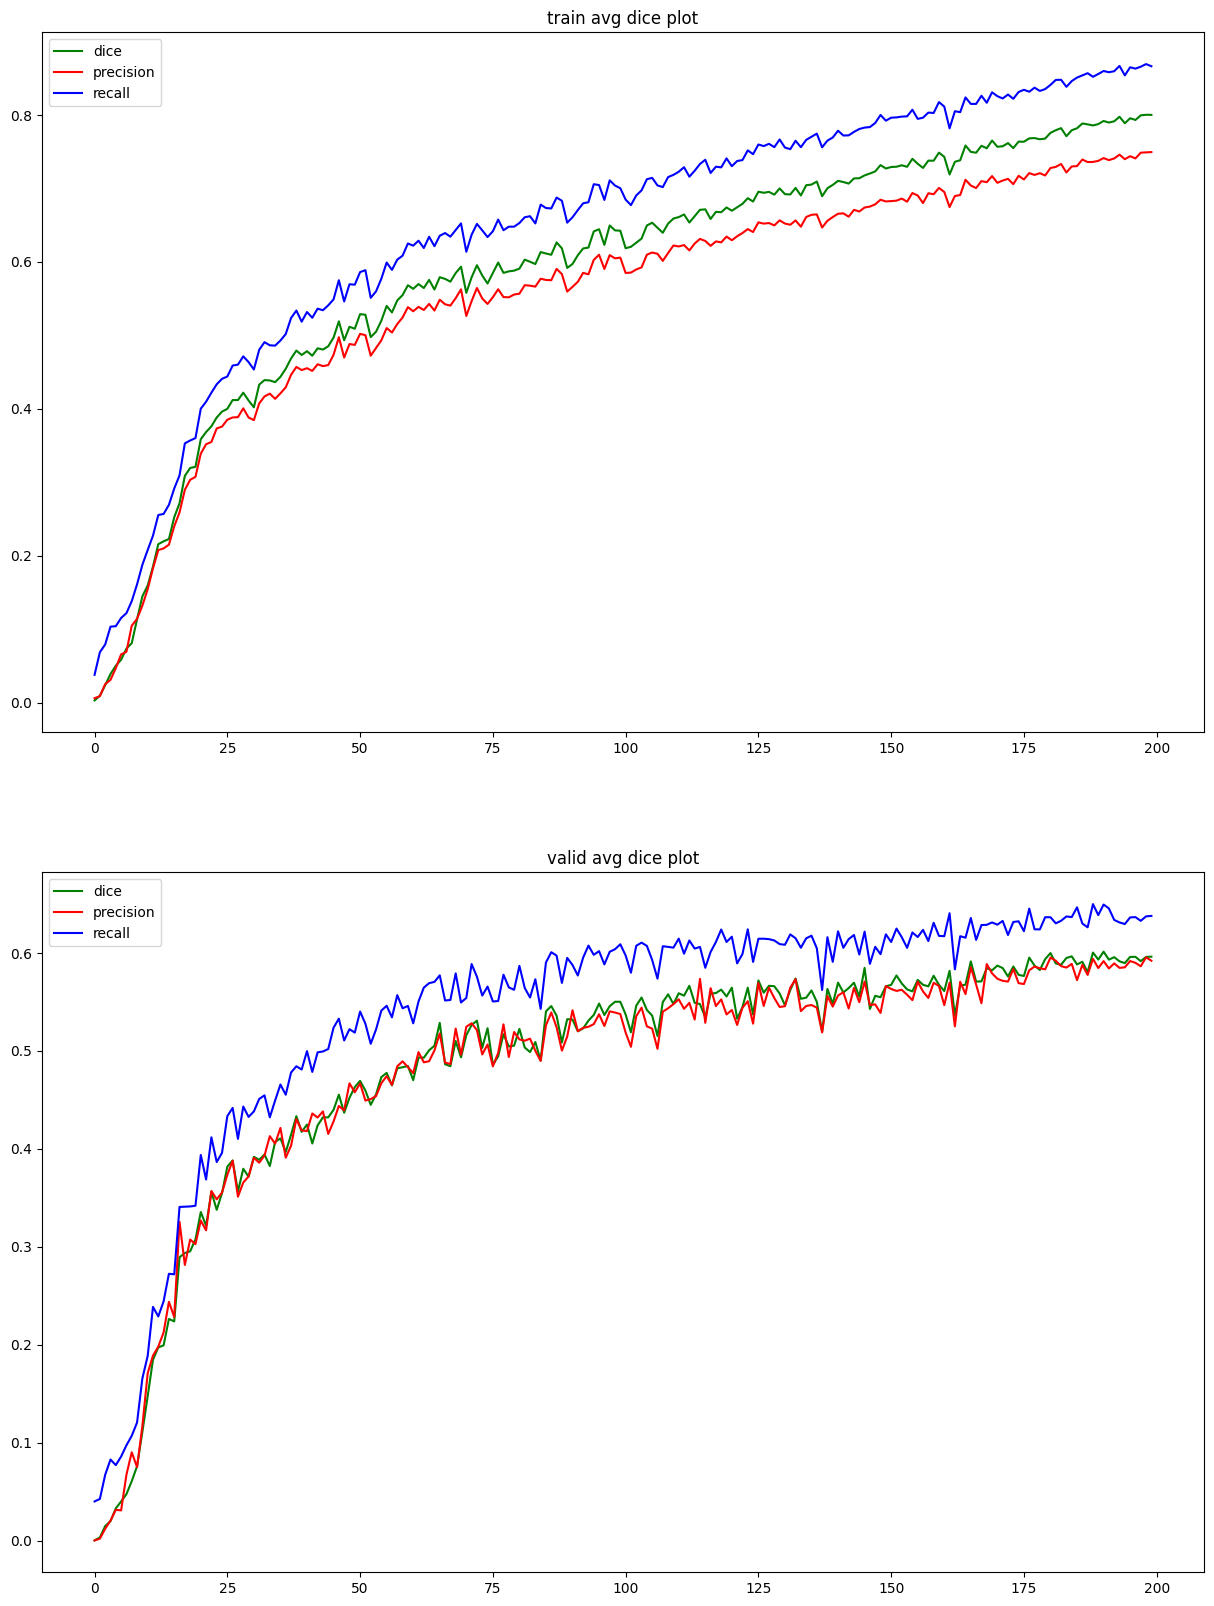

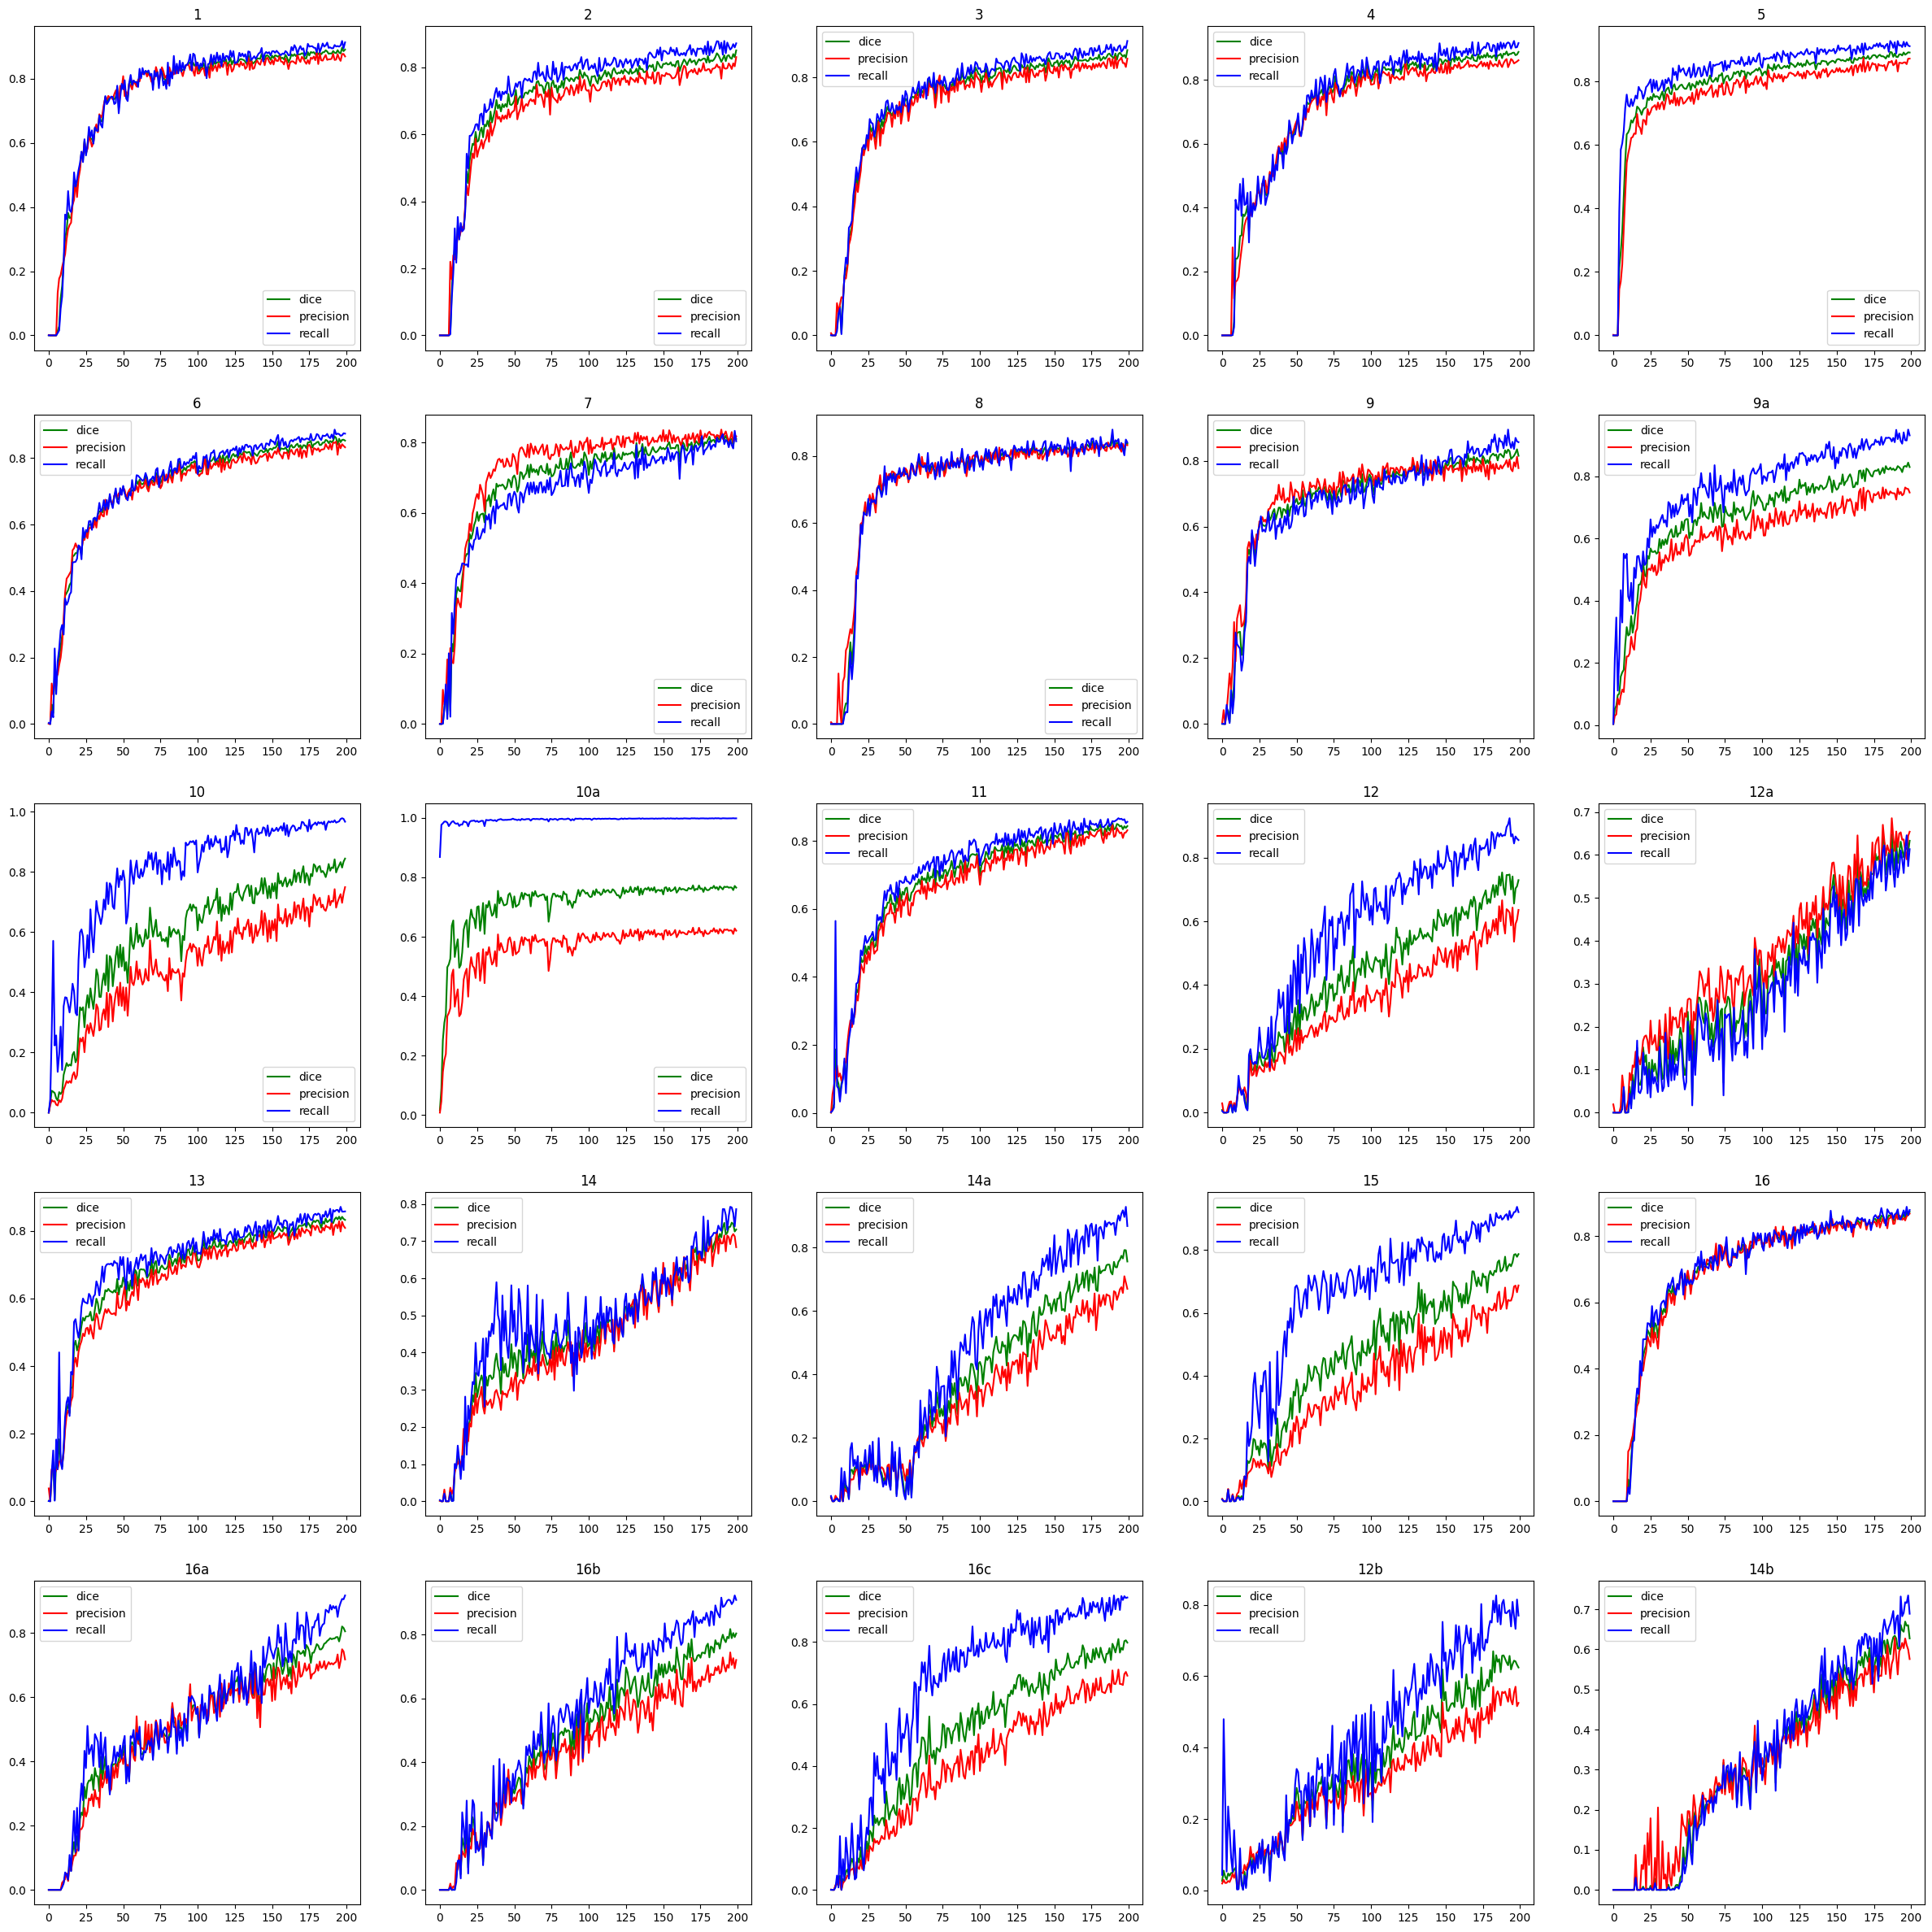

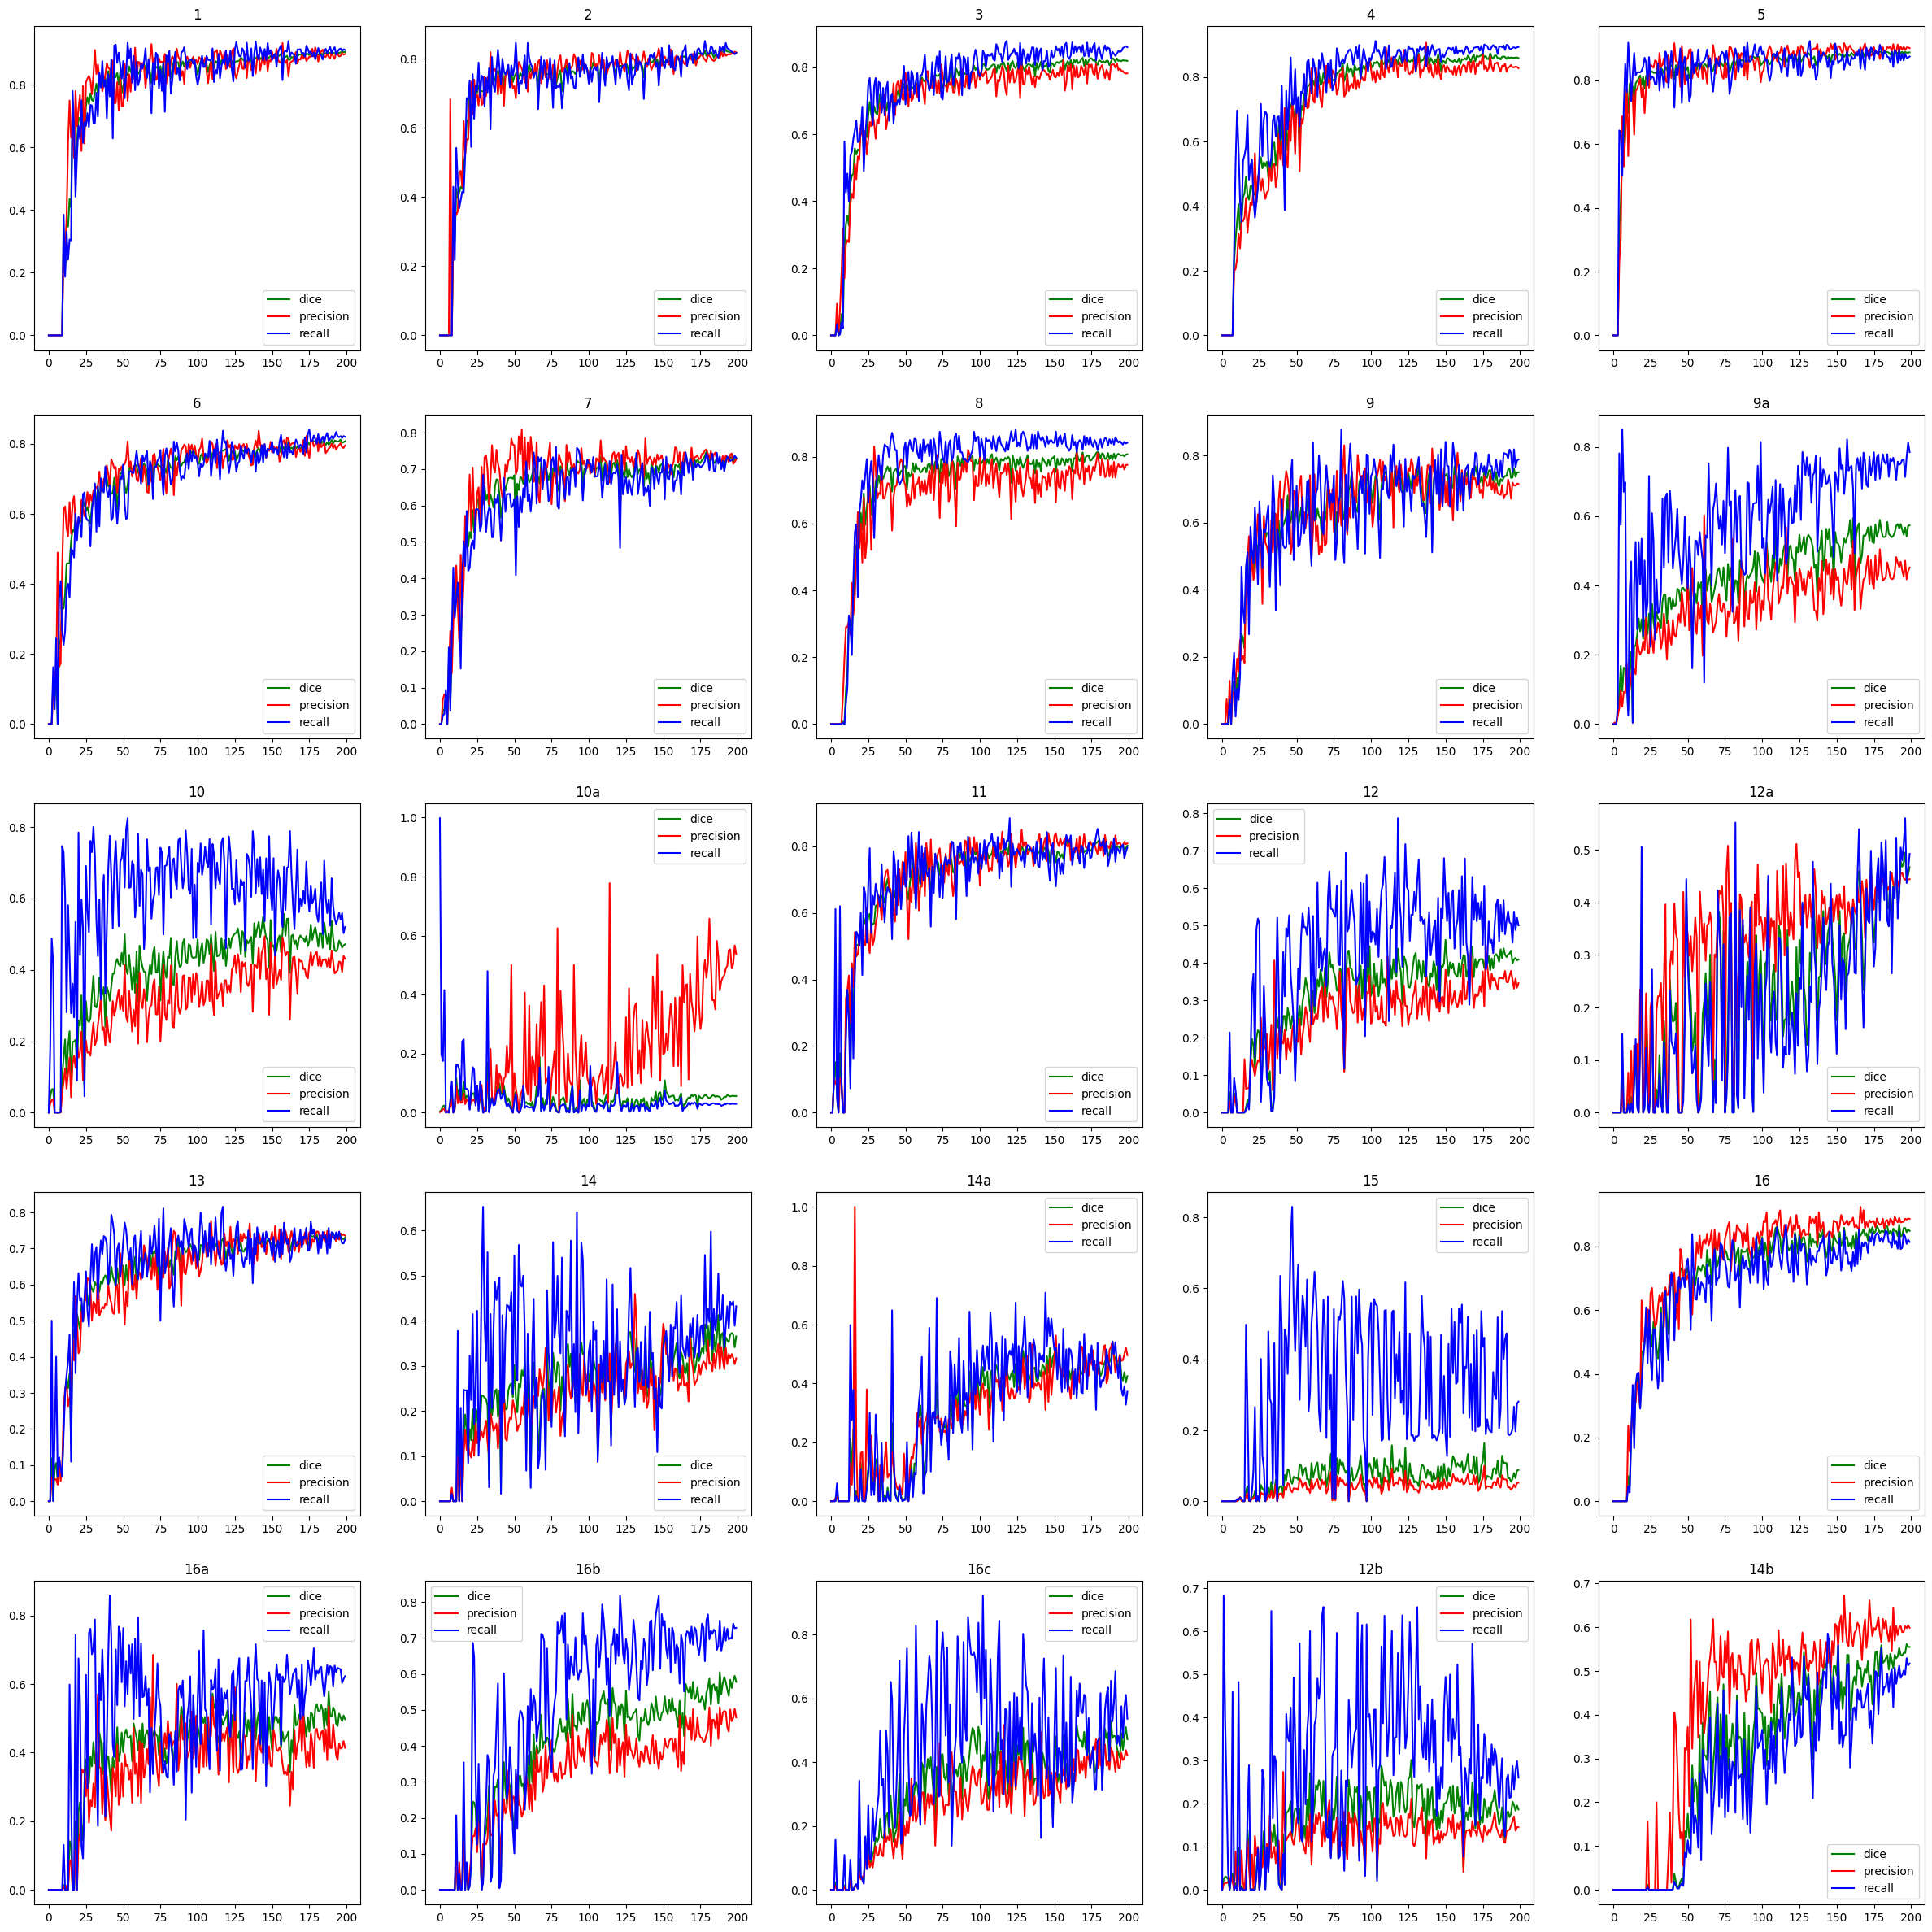

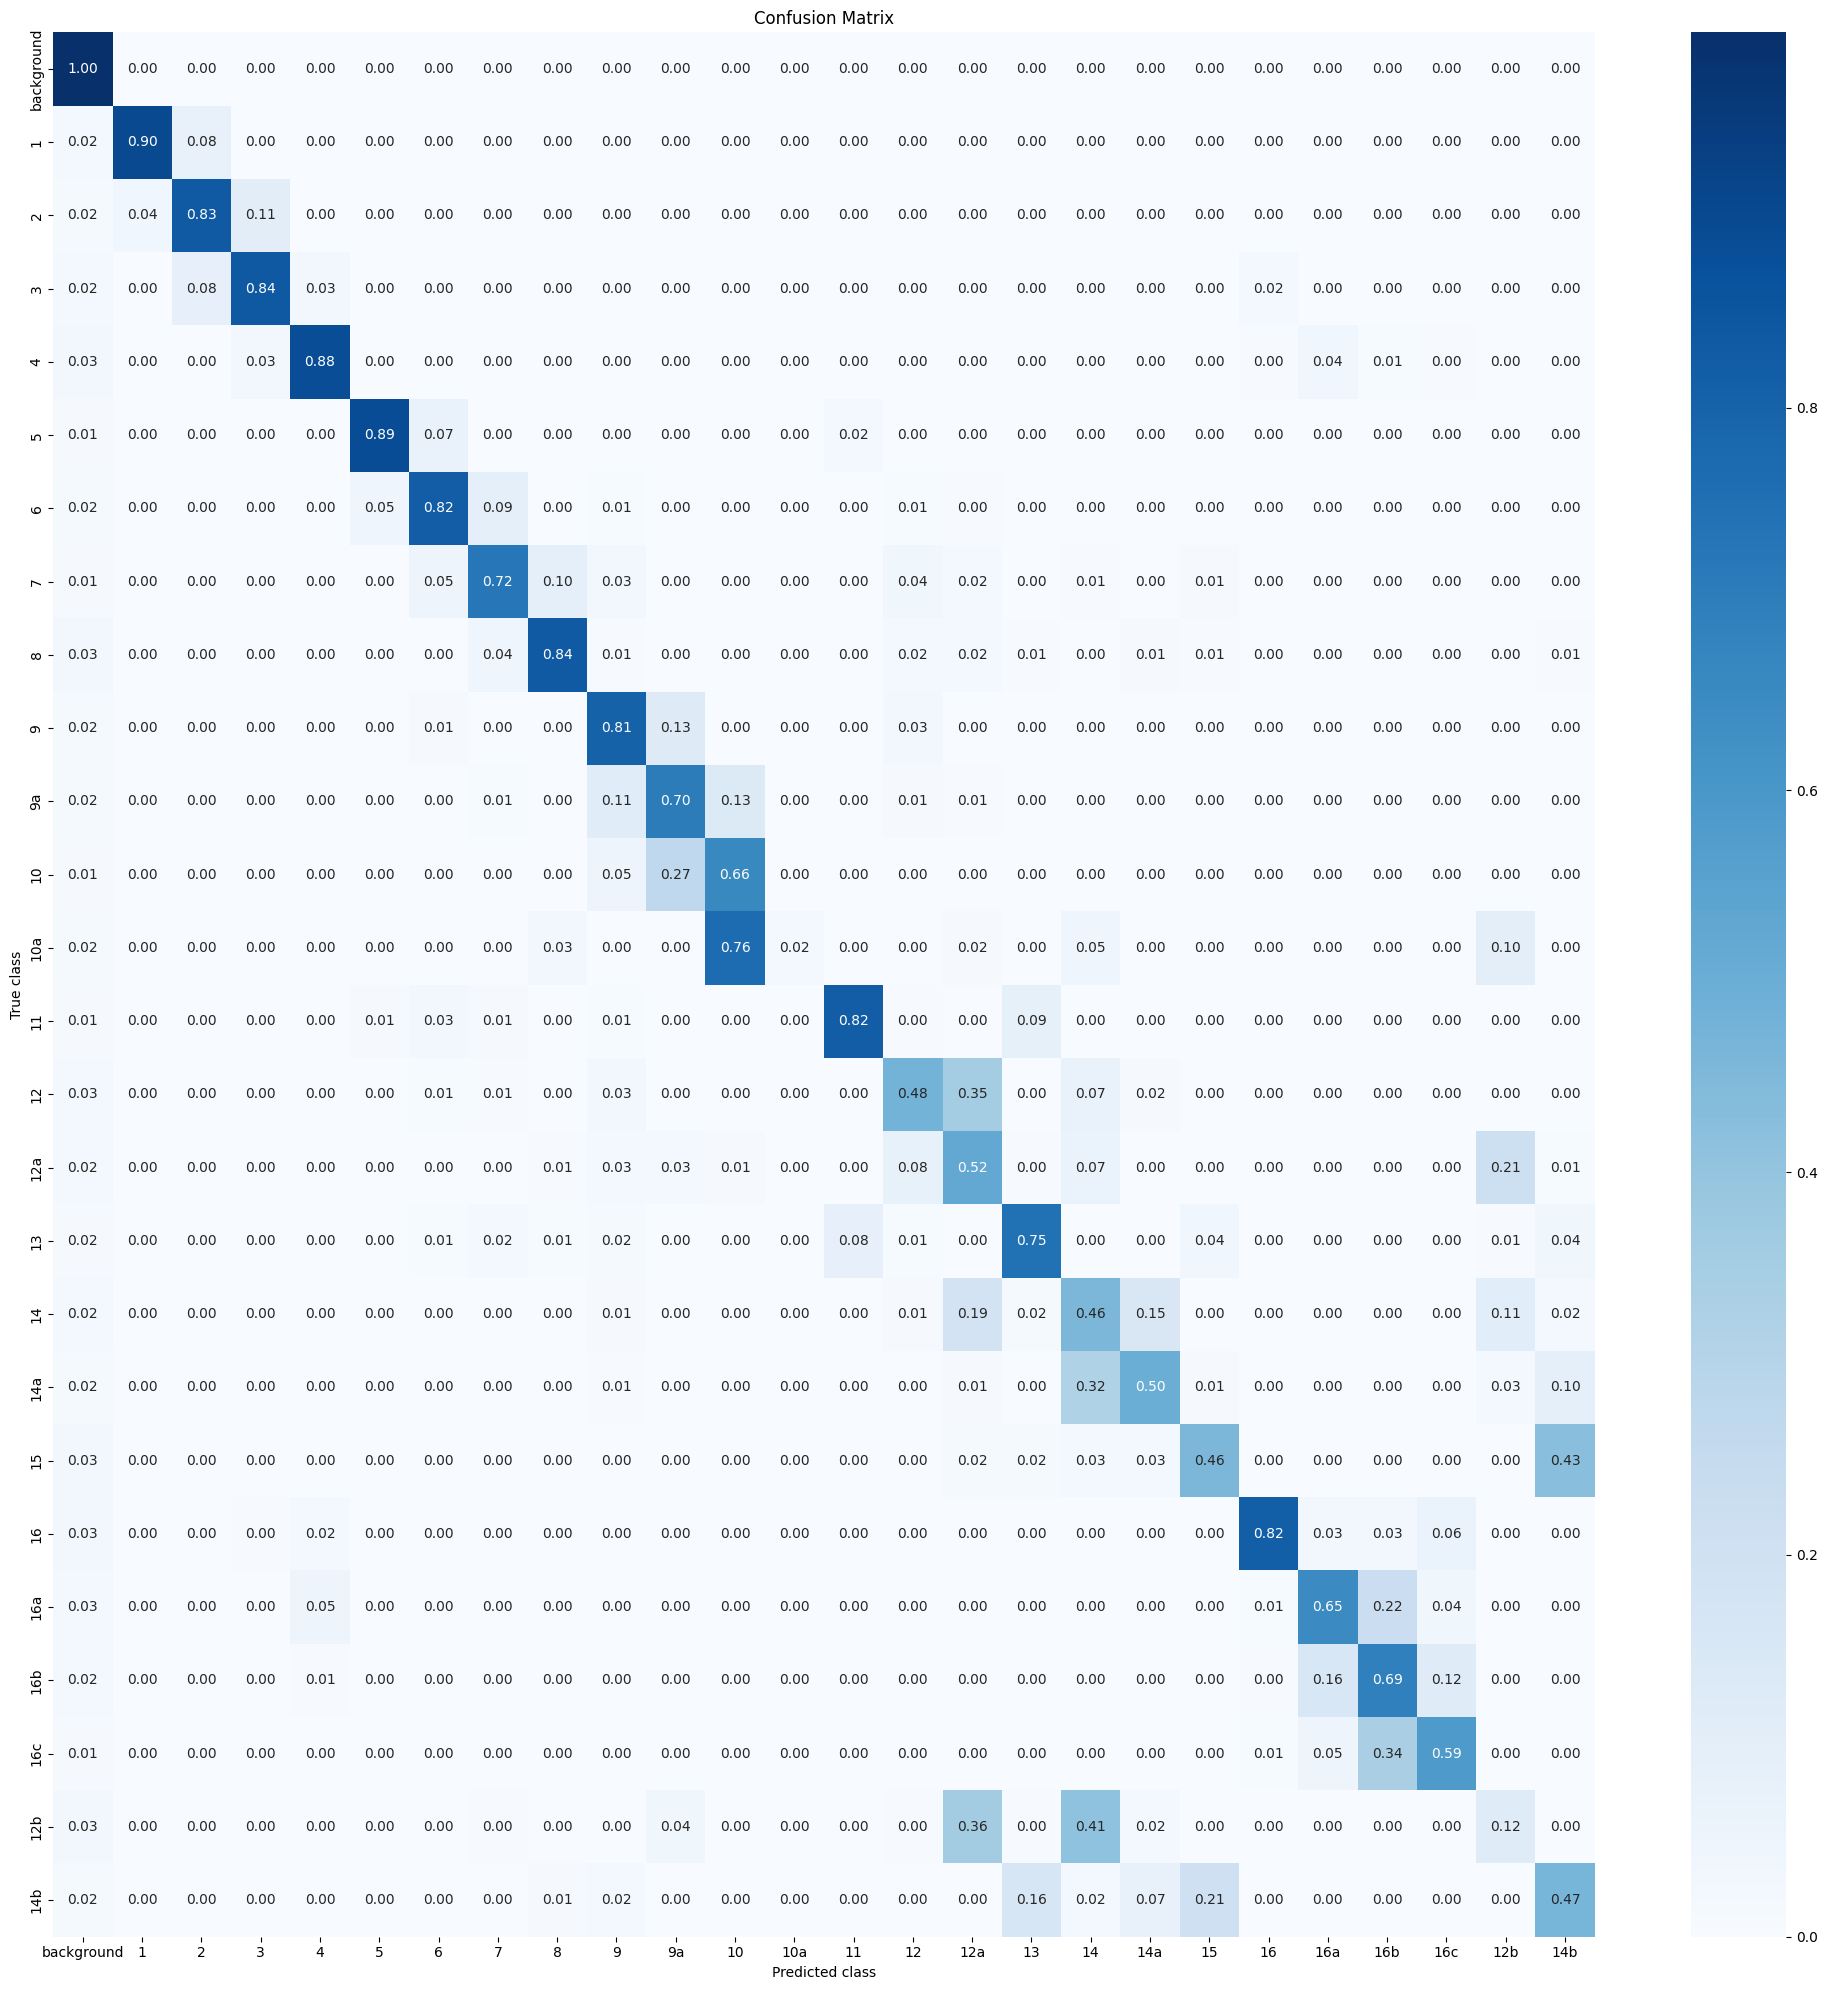

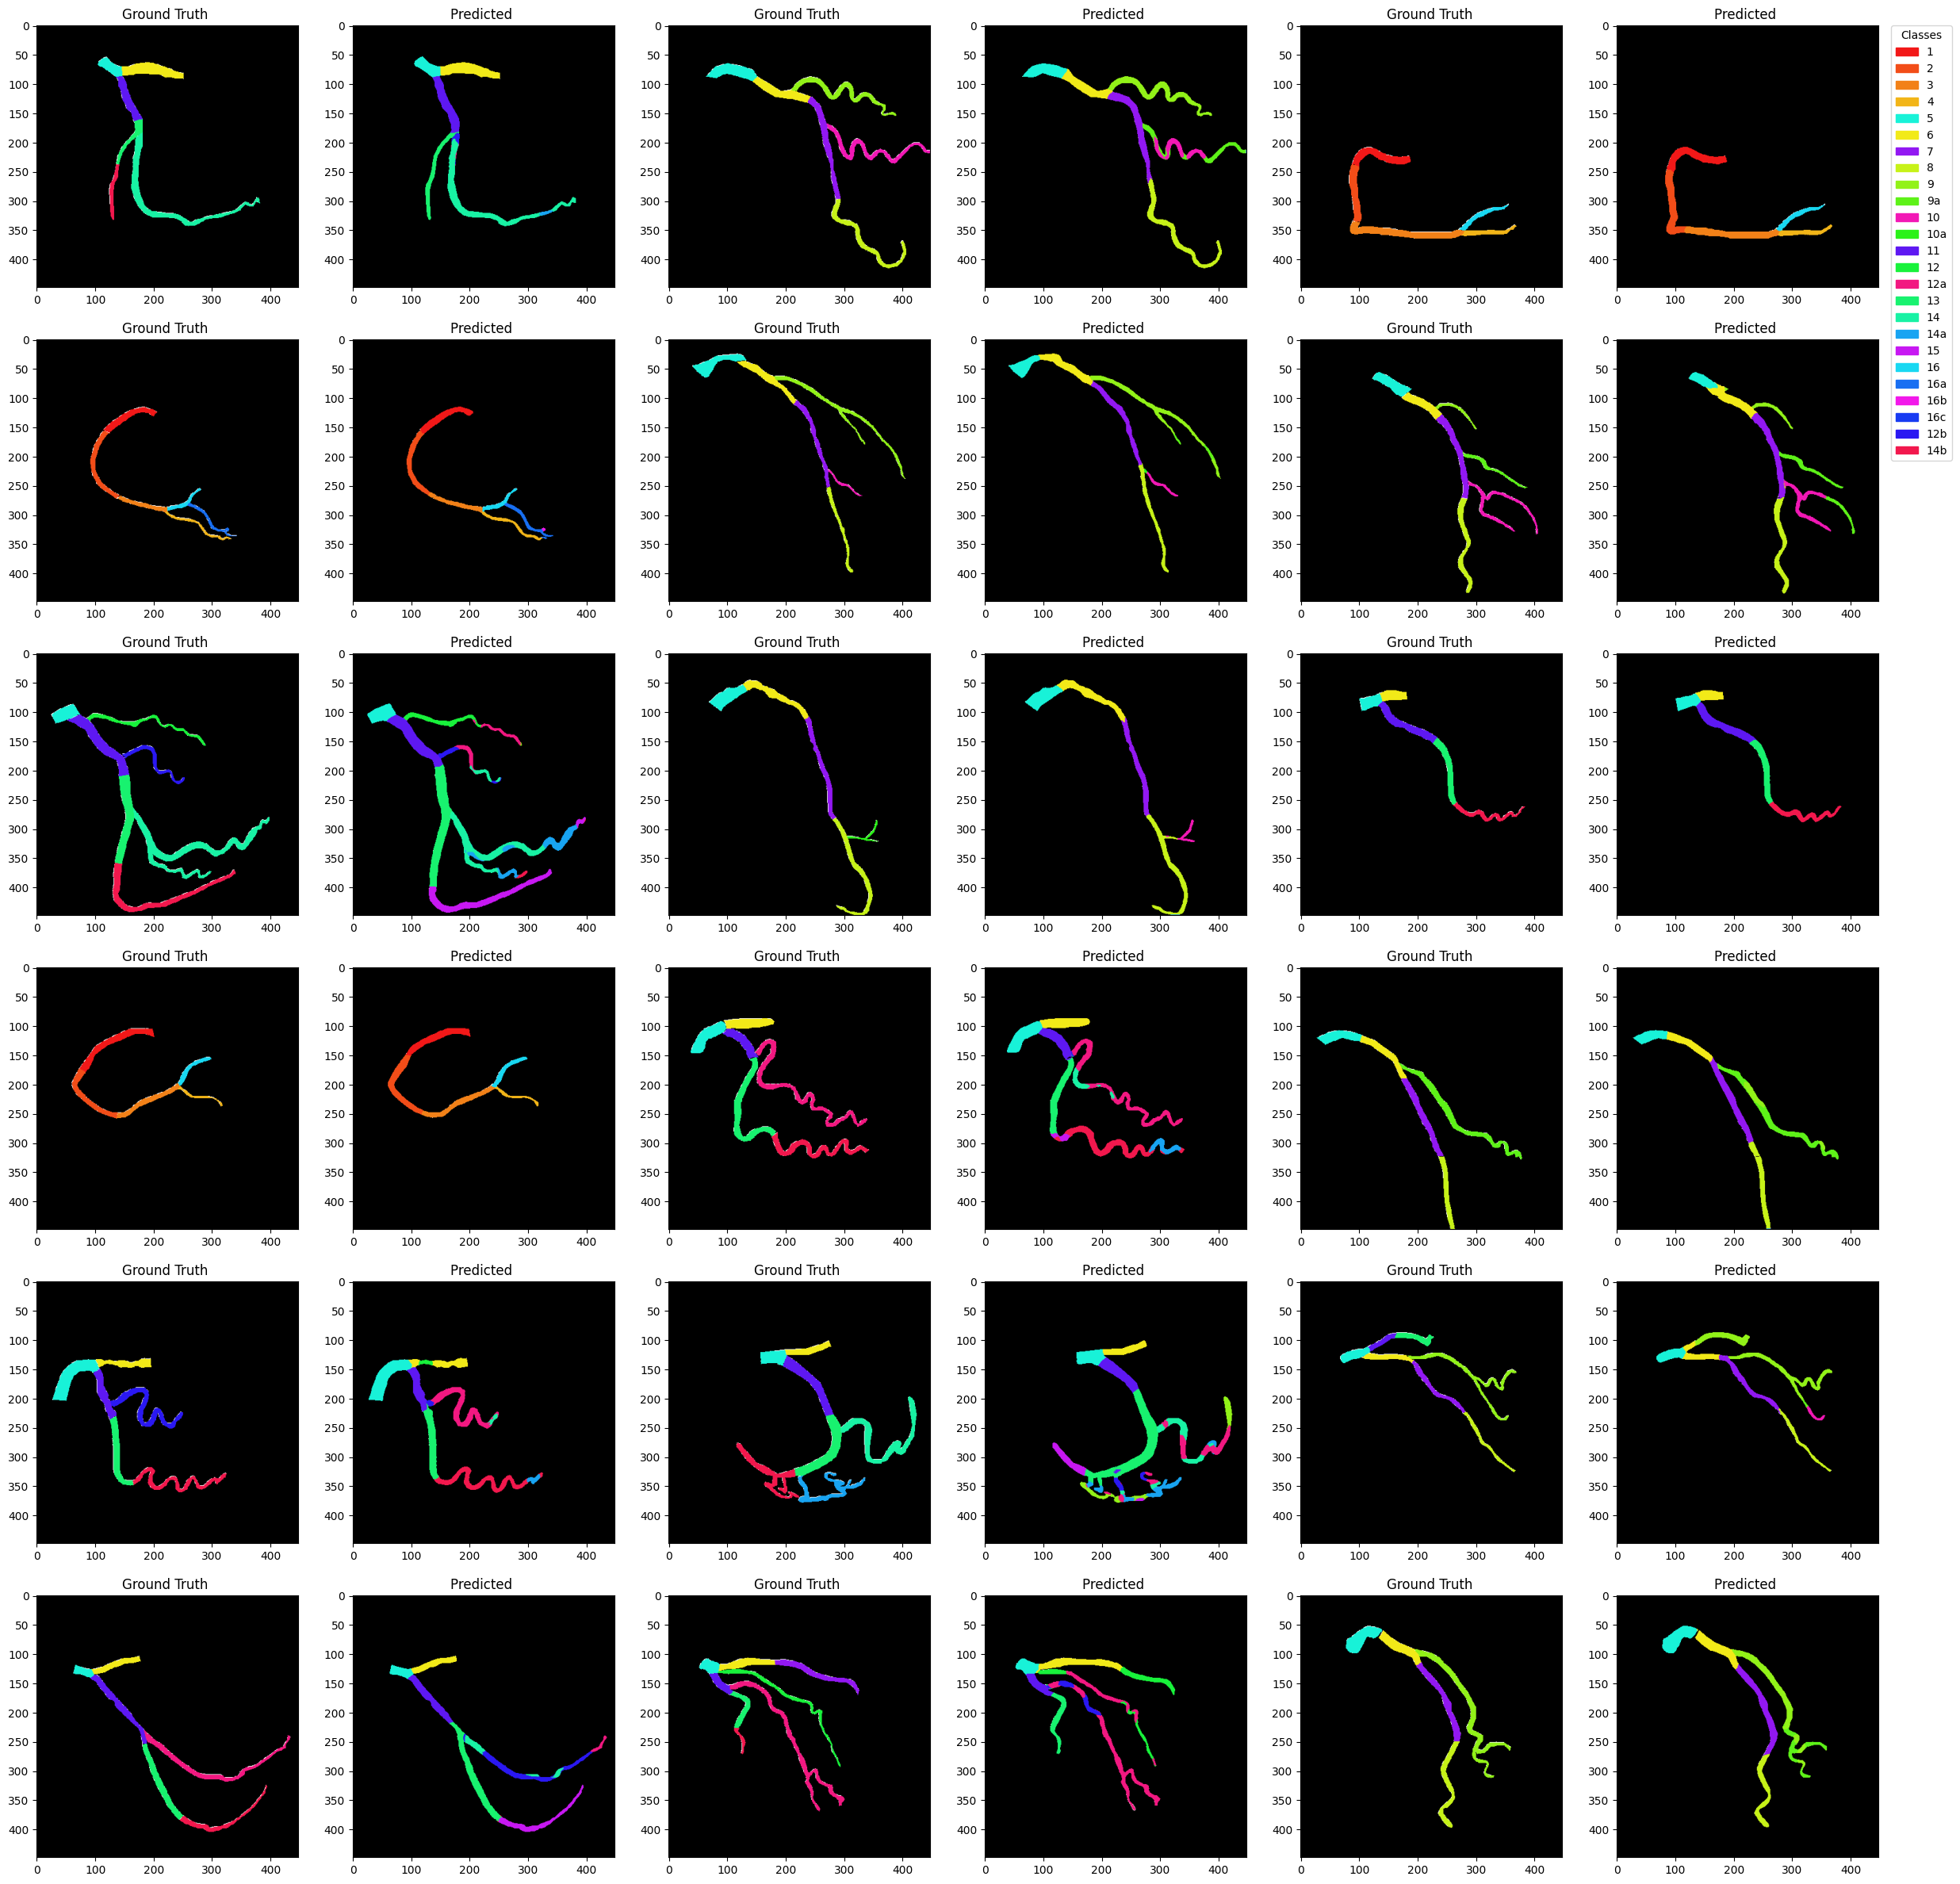

In [10]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"]
)